In [4]:
import pandas as pd
import numpy as np


file_path = 'D:\pythonfiles\__pycache__\question and answer\ipseity-daily-responses.csv'  # 替换为你的实际文件路径
df_raw = pd.read_csv(file_path)
print(df_raw.head())

<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\86151\AppData\Local\Temp\ipykernel_19272\251765934.py:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  file_path = 'D:\pythonfiles\__pycache__\question and answer\ipseity-daily-responses.csv'  # 替换为你的实际文件路径


  hashed_respondent_id    obs_date             signifier  endorsed
0         054b34e983ce  2025-07-08            AI creator         1
1         054b34e983ce  2025-07-08              American         1
2         054b34e983ce  2025-07-08  Cleveland Browns fan         0
3         054b34e983ce  2025-07-08              Democrat         0
4         054b34e983ce  2025-07-08    Detroit Tigers fan         0


In [5]:
# 按hashed_respondent_id和signifier分组，保留每组第一条记录（首次出现的回答）
df_dedup = df_raw.drop_duplicates(subset=['hashed_respondent_id', 'signifier'], keep='first')

print(f"去重前数据量：{len(df_raw)}条，去重后数据量：{len(df_dedup)}条")

去重前数据量：589734条，去重后数据量：450959条


In [9]:
status_response_count = df_dedup.groupby('signifier')['hashed_respondent_id'].nunique()

In [15]:
valid_statuses = status_response_count[status_response_count >= 300].index.tolist()
print(f"回答人数≥300的状态数量：{len(valid_statuses)}个，分别是：{valid_statuses}")

回答人数≥300的状态数量：677个，分别是：['ADHD', 'AI creator', 'AI enthusiast', 'American', 'Anarchist', 'Aquarius', 'Aries', 'Arizona Cardinals fan', 'Arizona Diamondbacks fan', 'Atlanta Braves fan', 'Atlanta Falcons fan', 'Baltimore Orioles fan', 'Baltimore Ravens fan', 'Baptist', 'Boston Celtics fan', 'Boston Red Sox fan', 'Brooklyn Nets fan', 'Buddhist', 'Buffalo Bills fan', 'CEO', 'COVID survivor', 'Cancer', 'Capricorn', 'Carolina Panthers fan', 'Catholic', 'Charlotte Hornets fan', 'Chicago Bears fan', 'Chicago Bulls fan', 'Chicago Cubs fan', 'Chicago White Sox fan', 'Christian', 'Cincinnati Bengals fan', 'Cincinnati Reds fan', 'Cleveland Browns fan', 'Cleveland Cavaliers fan', 'Cleveland Guardians fan', 'Colorado Rockies fan', 'Communist', 'Confucian', 'Dallas Cowboys fan', 'Dallas Mavericks fan', 'Democrat', 'Democratic Socialist', 'Denver Broncos fan', 'Denver Nuggets fan', 'Detroit Lions fan', 'Detroit Pistons fan', 'Detroit Tigers fan', 'Disney fan', 'English speaker', 'Episcopalian', 'Evange

In [ ]:
# 过滤原始去重数据，仅保留有效状态
df_filtered = df_dedup[df_dedup['signifier'].isin(valid_statuses)]
print(f"过滤后数据量：{len(df_filtered)}条（删除了{len(df_dedup) - len(df_filtered)}条回答人数<300的状态数据）")


过滤后数据量：443140条（删除了7819条回答人数<30的状态数据）


In [17]:
endorsed_map = {1: 1, 0: -1, np.nan: 0, '': 0}
df_filtered['endorsed_num'] = df_filtered['endorsed'].map(endorsed_map).fillna(0)
# 以hashed_respondent_id为索引，signifier为列名，endorsed_num为值
df_pivot = df_filtered.pivot(index='hashed_respondent_id', columns='signifier', values='endorsed_num')
print(df_pivot.head())

signifier             ADHD  AI creator  AI enthusiast  American  Anarchist  \
hashed_respondent_id                                                         
0020a6cbe91f           NaN        -1.0            NaN       1.0        NaN   
004ded854c14           NaN         1.0            NaN       1.0        NaN   
0050ffa3edac           NaN         1.0            NaN       1.0        NaN   
006e9872b249           NaN         NaN            NaN       1.0        NaN   
008868b524da           NaN        -1.0            NaN       1.0        NaN   

signifier             Aquarius  Aries  Arizona Cardinals fan  \
hashed_respondent_id                                           
0020a6cbe91f               NaN    NaN                    NaN   
004ded854c14               NaN    NaN                   -1.0   
0050ffa3edac               NaN    NaN                    NaN   
006e9872b249               NaN    NaN                    NaN   
008868b524da               NaN    NaN                    NaN   

sign

In [18]:
fill_value = 0  # 替换为你的默认值（0/-1/1）
df_final = df_pivot.fillna(fill_value)


In [19]:
output_file = 'hashed_status_bifurcation_table_filtered.csv'
df_final.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"二联表生成成功，已保存至：{output_file}")
print("\n二联表前5行预览：")
print(df_final.head())

二联表生成成功，已保存至：hashed_status_bifurcation_table_filtered.csv

二联表前5行预览：
signifier             ADHD  AI creator  AI enthusiast  American  Anarchist  \
hashed_respondent_id                                                         
0020a6cbe91f           0.0        -1.0            0.0       1.0        0.0   
004ded854c14           0.0         1.0            0.0       1.0        0.0   
0050ffa3edac           0.0         1.0            0.0       1.0        0.0   
006e9872b249           0.0         0.0            0.0       1.0        0.0   
008868b524da           0.0        -1.0            0.0       1.0        0.0   

signifier             Aquarius  Aries  Arizona Cardinals fan  \
hashed_respondent_id                                           
0020a6cbe91f               0.0    0.0                    0.0   
004ded854c14               0.0    0.0                   -1.0   
0050ffa3edac               0.0    0.0                    0.0   
006e9872b249               0.0    0.0                    0.0   


In [31]:
df1 = pd.read_csv('D:\pythonfiles\__pycache__\question and answer\hashed_status_bifurcation_table_filtered.csv', na_values=['0.0'])

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\86151\AppData\Local\Temp\ipykernel_19272\3191510377.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  df1 = pd.read_csv('D:\pythonfiles\__pycache__\question and answer\hashed_status_bifurcation_table_filtered.csv', na_values=['0.0'])


In [33]:
corr_matrix = df1.corr()
print("\n状态关联强度（相关性矩阵）前5行预览：")
print(corr_matrix.head())   


状态关联强度（相关性矩阵）前5行预览：
                   ADHD  AI creator  AI enthusiast  American  Anarchist  \
ADHD           1.000000   -0.038752       0.026207  0.050517        NaN   
AI creator    -0.038752    1.000000       0.470081  0.007909   0.021914   
AI enthusiast  0.026207    0.470081       1.000000 -0.018787  -0.096088   
American       0.050517    0.007909      -0.018787  1.000000   0.025239   
Anarchist           NaN    0.021914      -0.096088  0.025239   1.000000   

               Aquarius     Aries  Arizona Cardinals fan  \
ADHD           0.107199 -0.088940              -0.080582   
AI creator     0.049841  0.069850               0.011358   
AI enthusiast  0.004038  0.257878               0.052508   
American       0.028601  0.022758               0.024139   
Anarchist           NaN       NaN              -0.014505   

               Arizona Diamondbacks fan  Atlanta Braves fan  ...     woman  \
ADHD                          -0.064299           -0.103807  ...  0.152722   
AI creator 

In [34]:
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

print("\n状态关联强度（相关性矩阵）前5行预览：")
print(upper_triangle.head())


状态关联强度（相关性矩阵）前5行预览：
               ADHD  AI creator  AI enthusiast  American  Anarchist  Aquarius  \
ADHD            NaN   -0.038752       0.026207  0.050517        NaN  0.107199   
AI creator      NaN         NaN       0.470081  0.007909   0.021914  0.049841   
AI enthusiast   NaN         NaN            NaN -0.018787  -0.096088  0.004038   
American        NaN         NaN            NaN       NaN   0.025239  0.028601   
Anarchist       NaN         NaN            NaN       NaN        NaN       NaN   

                  Aries  Arizona Cardinals fan  Arizona Diamondbacks fan  \
ADHD          -0.088940              -0.080582                 -0.064299   
AI creator     0.069850               0.011358                  0.096481   
AI enthusiast  0.257878               0.052508                  0.185507   
American       0.022758               0.024139                  0.024907   
Anarchist           NaN              -0.014505                 -0.022222   

               Atlanta Braves fan  

In [ ]:
corr_pairs = upper_triangle.stack().reset_index()
corr_pairs.columns = ['Column_1', 'Column_2', 'Correlation']
print("\n状态关联强度（相关性矩阵）前5行预览：")
print(corr_pairs.head())



状态关联强度（相关性矩阵）前5行预览：
  Column_1       Column_2  Correlation
0     ADHD           ADHD          NaN
1     ADHD     AI creator    -0.038752
2     ADHD  AI enthusiast     0.026207
3     ADHD       American     0.050517
4     ADHD      Anarchist          NaN


<bound method NDFrame.describe of        Column_1       Column_2  Correlation
0          ADHD           ADHD          NaN
1          ADHD     AI creator    -0.038752
2          ADHD  AI enthusiast     0.026207
3          ADHD       American     0.050517
4          ADHD      Anarchist          NaN
...         ...            ...          ...
458324        🫠          young          NaN
458325        🫠       youtuber          NaN
458326        🫠              😍          NaN
458327        🫠              🤒          NaN
458328        🫠              🫠          NaN

[458329 rows x 3 columns]>

In [40]:
count=corr_pairs[abs(corr_pairs['Correlation']) > 0.7]
print(f"\n相关性绝对值大于0.7的状态对数量：{len(count)}个")


相关性绝对值大于0.7的状态对数量：516个


In [42]:
corr_pairs_filtered = corr_pairs[abs(corr_pairs['Correlation']) > 0.7]
print("\n相关性绝对值大于0.7的状态对前5行预览：")
print(corr_pairs_filtered.head())
corr_pairs_filtered.to_csv('correlation_pairs_filtered.csv', index=False, encoding='utf-8-sig')


相关性绝对值大于0.7的状态对前5行预览：
                   Column_1                  Column_2  Correlation
4017               Aquarius              truck driver     0.700529
4139                  Aries    Los Angeles Angels fan     1.000000
4370                  Aries             event planner     0.808122
4747  Arizona Cardinals fan  Arizona Diamondbacks fan     0.767184
4857  Arizona Cardinals fan          Phoenix Suns fan     0.837066


In [43]:

import networkx as nx
import matplotlib.pyplot as plt

# 检查必要的列是否存在
required_columns = ['Column_1', 'Column_2', 'Correlation']
if not all(col in corr_pairs_filtered.columns for col in required_columns):
    print(f"错误: CSV文件中缺少必要的列。需要的列: {required_columns}")
    exit()


In [44]:

# 2. 创建图对象
G = nx.Graph()


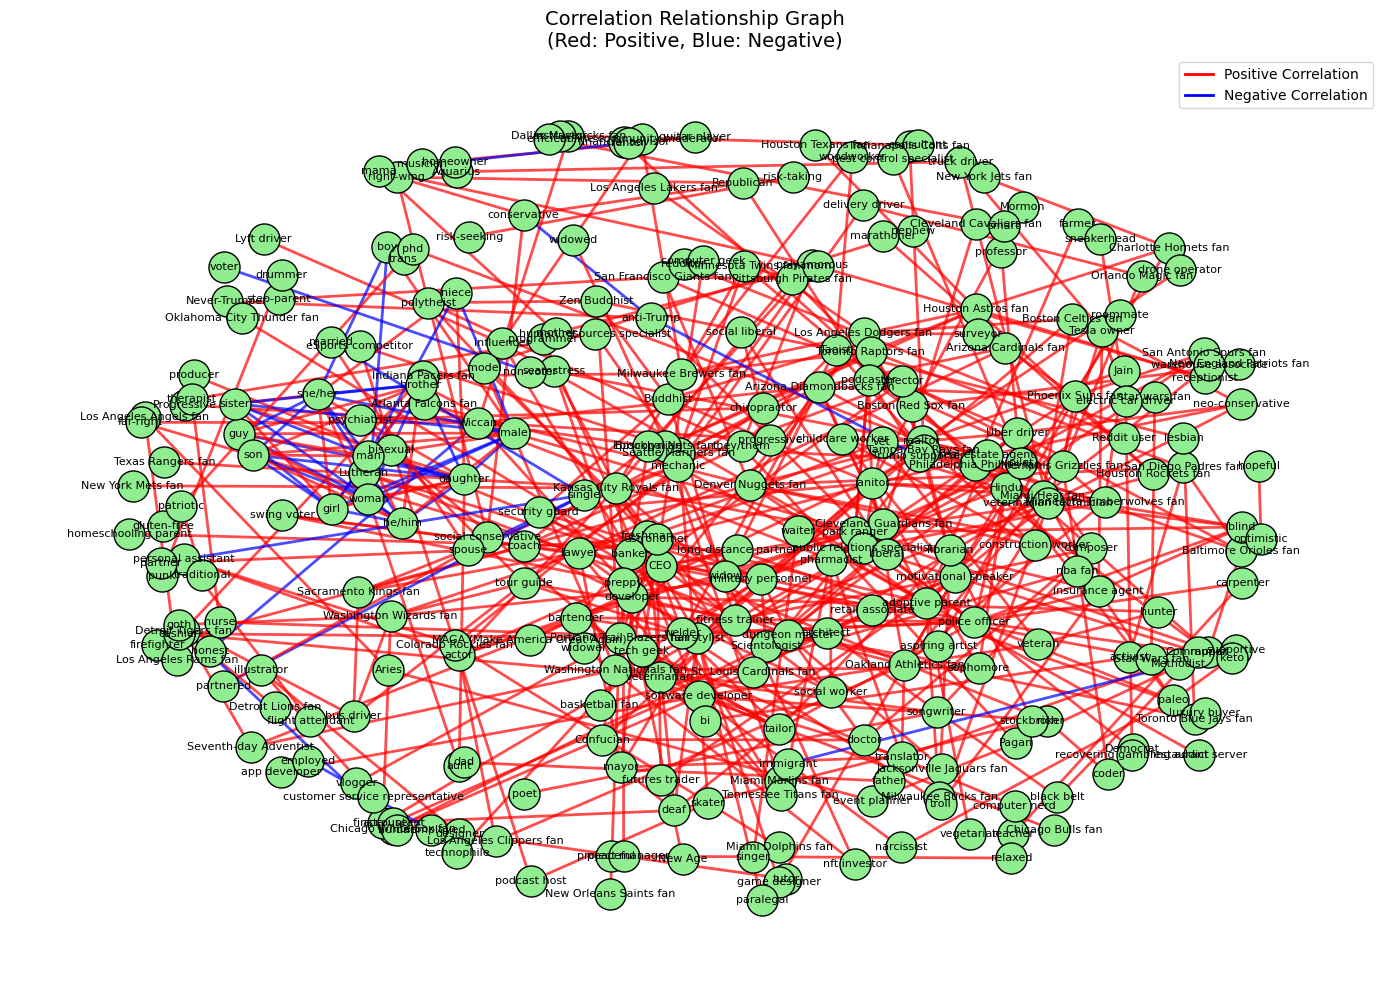

In [ ]:

# 3. 添加节点和边
# 遍历DataFrame的每一行
for index, row in corr_pairs_filtered.iterrows():
    node1 = row['Column_1']
    node2 = row['Column_2']
    correlation = row['Correlation']
    
    # 添加节点 (networkx会自动处理重复节点)
    G.add_node(node1)
    G.add_node(node2)
    
    # 添加边，并将相关系数作为属性存储
    G.add_edge(node1, node2, correlation=correlation)

# 4. 设置边的颜色
# 根据Correlation的正负设置颜色：正相关为红色，负相关为蓝色
edge_colors = []
for u, v, data in G.edges(data=True):
    corr = data['correlation']
    if corr >= 0:
        edge_colors.append('red')   # 正相关
    else:
        edge_colors.append('blue')  # 负相关

# 5. 绘制图形
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50) # 使用弹簧布局，k值调整节点间距

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightgreen', edgecolors='black')

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2, alpha=0.7)

# 添加标题和图例
plt.title('Correlation Relationship Graph\n(Red: Positive, Blue: Negative)', fontsize=14)
plt.axis('off') # 关闭坐标轴

# 创建自定义图例
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', lw=2, label='Positive Correlation'),
                   Line2D([0], [0], color='blue', lw=2, label='Negative Correlation')]
plt.legend(handles=legend_elements, loc='best')

# 调整布局以防止标签被裁剪
plt.tight_layout()

# 6. 显示图像
plt.show()

# 如果需要保存图像，可以取消下面这行的注释
# plt.savefig('correlation_graph.png', dpi=300, bbox_inches='tight')

In [ ]:
from pyvis.network import Network

# ... (前面读取数据和筛选 corr_pairs 的代码相同) ...

# 创建网络
net = Network(height="750px", width="100%", directed=False, notebook=True)


In [47]:
nodes = list(set(corr_pairs_filtered['Column_1']).union(set(corr_pairs_filtered['Column_2'])))
# 添加节点
for node in nodes:
    net.add_node(node, label=node, title=node, color="#3498db")

# 添加边
for _, row in corr_pairs_filtered.iterrows():
    color = "#2ecc71" if row['Correlation'] > 0 else "#e74c3c"
    width = abs(row['Correlation']) * 5
    net.add_edge(row['Column_1'], row['Column_2'], 
                 value=abs(row['Correlation']), 
                 color=color, 
                 width=width,
                 title=f"相关性: {row['Correlation']:.3f}")

# 配置物理引擎 (力导向)
net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 100,
      "springConstant": 0.08
    },
    "solver": "forceAtlas2Based",
    "stabilization": { "enabled": true }
  }
}
""")

# 生成并打开 HTML
net.show("label_relationship_graph.html", notebook=False)

label_relationship_graph.html
